In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from scipy.signal import butter, filtfilt, resample
from sklearn.preprocessing import StandardScaler, LabelEncoder
import mne
from glob import glob

# Filter selection: 'data_curation' or 'notebook'
# 'data_curation': Uses filter from data_curation.py (lowcut=8, highcut=30, order=5)
# 'notebook': Uses original notebook filter (lowcut=4, highcut=40, order=4)
FILTER_TYPE = 'data_curation'  # Change this to switch between filters

# Trial detection method: 'automatic' or 'trial_index'
# 'automatic': Uses phase sequence detection from data_curation.py (detects baseline->instruction->reach/stimulus)
# 'trial_index': Uses pre-existing trial_index column (original notebook method)
TRIAL_DETECTION_METHOD = 'trial_index'  # Change this to switch between detection methods

In [2]:
files = sorted(glob('data/2_class/EEG_bar_trials_*.csv'))
print(f"Found {len(files)} files:")
for f in files:
    print(f"  - {f}")

if len(files) == 0:
    print("WARNING: No files found! Check your data directory path.")
else:
    data_list = []
    max_trial_index = 0
    
    # Load files and make trial_index unique across files
    for f in files:
        df = pd.read_csv(f)
        if 'trial_index' in df.columns:
            # Offset trial_index to make it unique across files
            df['trial_index'] = df['trial_index'] + max_trial_index
            max_trial_index = df['trial_index'].max() + 1
        data_list.append(df)
    
    data = pd.concat(data_list, ignore_index=True)
    
    # Filter out class_label == 0 from all files
    initial_shape = data.shape
    data = data[data['class_label'] != 0]
    filtered_shape = data.shape
    print(f"Initial data shape: {initial_shape}")
    print(f"After filtering class_label == 0: {filtered_shape}")
    print(f"Removed {initial_shape[0] - filtered_shape[0]} rows with class_label == 0")
    
    print(f"Combined data shape: {data.shape}")
    print(f"Unique trials: {data['trial_index'].nunique()}")
    print(f"Unique class labels: {data['class_label'].unique()}")

Found 4 files:
  - data/2_class\EEG_bar_trials_20_classes_2_20251222_184334.csv
  - data/2_class\EEG_bar_trials_20_classes_2_20251222_185333.csv
  - data/2_class\EEG_bar_trials_30_classes_2_20251222_175547.csv
  - data/2_class\EEG_bar_trials_30_classes_2_20251222_181846.csv
Initial data shape: (454896, 22)
After filtering class_label == 0: (454876, 22)
Removed 20 rows with class_label == 0
Combined data shape: (454876, 22)
Unique trials: 200
Unique class labels: [2 1]


In [3]:
def ensure_fixed_length(arr, n_samples=2250, n_channels=8):
    """Ensure a 2D array has exactly n_samples rows and n_channels columns by truncating or padding with zeros."""
    if arr is None or arr.size == 0:
        return np.zeros((n_samples, n_channels), dtype=float)

    rows, cols = arr.shape
    # fix columns
    if cols > n_channels:
        arr = arr[:, :n_channels]
    elif cols < n_channels:
        pad_cols = np.zeros((rows, n_channels - cols), dtype=arr.dtype)
        arr = np.hstack([arr, pad_cols])

    # fix rows
    if rows >= n_samples:
        return arr[:n_samples, :]
    else:
        pad = np.zeros((n_samples - rows, arr.shape[1]), dtype=arr.dtype)
        return np.vstack([arr, pad])


def extract_eeg_trials_automatic(data: pd.DataFrame, eeg_col_start=5, eeg_col_end=13):
    """
    Automatic trial detection from data_curation.py - detects trials by phase sequence.
    Adapted to work with notebook's data structure (uses 'class_label' instead of 'task',
    and handles 'stimulus' phase instead of 'reach').
    
    Parameters:
        data (pd.DataFrame): DataFrame with 'phase', 'class_label', and EEG columns
        eeg_col_start, eeg_col_end: Column indices for EEG channels
    
    Returns:
        trials (List[np.ndarray]): List of EEG data arrays (shape: [time_steps, 8])
        labels (List): Corresponding class label for each trial
        splits (List): Corresponding split label for each trial (if available)
    """
    # Get EEG column names
    eeg_cols = data.columns[eeg_col_start:eeg_col_end]
    
    # Detect phase or class_label changes
    changes = (data["phase"] != data["phase"].shift()) | (
        data["class_label"] != data["class_label"].shift()
    )
    changed_rows = data[changes]
    
    trials_raw = []
    current_label = None
    current_phases = []
    start_idx = None
    # Expected phases: baseline -> instruction -> stimulus (or baseline -> stimulus if no instruction)
    # Try both sequences
    expected_phases_1 = ["baseline", "instruction", "stimulus"]
    expected_phases_2 = ["baseline", "stimulus"]
    change_indices = changed_rows.index.tolist()
    
    for i, idx in enumerate(change_indices):
        row = changed_rows.loc[idx]
        label = row["class_label"]
        phase = row["phase"]
        
        if current_label != label:
            current_label = label
            current_phases = []
            start_idx = None
        
        # Try full sequence first, then short sequence
        expected_phases = expected_phases_1 if "instruction" in data["phase"].values else expected_phases_2
        
        if len(current_phases) < len(expected_phases) and phase == expected_phases[len(current_phases)]:
            current_phases.append(phase)
            if len(current_phases) == 1:
                start_idx = idx
            
            if current_phases == expected_phases:
                end_idx = (
                    change_indices[i + 1] if i + 1 < len(change_indices) else len(data)
                )
                trial_df = data.loc[start_idx : end_idx - 1]
                trials_raw.append(trial_df)
                current_label = None
                current_phases = []
                start_idx = None
    
    # Extract EEG and labels
    trials = []
    labels = []
    splits = []
    for trial in trials_raw:
        eeg_data = trial.loc[:, eeg_cols].values
        task_label = trial["class_label"].iloc[0]
        split_label = trial["split"].iloc[0] if "split" in trial.columns else None
        trials.append(eeg_data)
        labels.append(task_label)
        splits.append(split_label)
    
    print(f"✅ Extracted {len(trials)} trials with labels (automatic detection).")
    return trials, labels, splits


def trails_by_time(data, fs=250, eeg_col_start=5, eeg_col_end=13, n_samples=1000, 
                   baseline_sec=3, apply_baseline_norm=True):
    """Build trials with fixed shape (n_samples, n_channels) for the MI (stimulus) phase."""
    trials = []
    trial_labels = []
    trial_splits = []
    trial_indices = []
    unique_trials = data['trial_index'].unique()
    print(f'Found {len(unique_trials)} unique trials.')

    eeg_cols = data.columns[eeg_col_start:eeg_col_end]
    n_channels = len(eeg_cols)
    baseline_samples = int(baseline_sec * fs)

    skipped_trials = []
    for trial in unique_trials:
        trial_data = data[data['trial_index'] == trial]
        
        # Skip if trial has no data
        if len(trial_data) == 0:
            skipped_trials.append((trial, "no data"))
            continue
        
        label = trial_data['class_label'].values[0] if 'class_label' in trial_data.columns else None
        split = trial_data['split'].values[0] if 'split' in trial_data.columns else None

        trial_baseline = trial_data[trial_data['phase'] == 'baseline']
        baseline_matrix = trial_baseline.loc[:, eeg_cols].values if len(trial_baseline) > 0 else np.zeros((0, n_channels))
        
        trial_MI = trial_data[trial_data['phase'] == 'stimulus']
        eeg_matrix = trial_MI.loc[:, eeg_cols].values if len(trial_MI) > 0 else np.zeros((0, n_channels))
        
        # Skip trial if it has no stimulus phase data (required for training)
        if len(eeg_matrix) == 0:
            skipped_trials.append((trial, "no stimulus phase"))
            continue

        if len(baseline_matrix) > baseline_samples:
            baseline_matrix = baseline_matrix[:baseline_samples]
        elif len(baseline_matrix) == 0:
            baseline_matrix = np.zeros((baseline_samples, n_channels))

        if apply_baseline_norm and len(baseline_matrix) > 0:
            baseline_mean = np.mean(baseline_matrix, axis=0, keepdims=True)
            baseline_std = np.std(baseline_matrix, axis=0, keepdims=True) + 1e-8
            if len(eeg_matrix) > 0:
                eeg_matrix = (eeg_matrix - baseline_mean) / baseline_std

        fixed = ensure_fixed_length(eeg_matrix, n_samples=n_samples, n_channels=n_channels)

        trials.append(fixed)
        trial_labels.append(label)
        trial_splits.append(split)
        trial_indices.append(trial)
    
    # Print info about skipped trials
    if skipped_trials:
        print(f'⚠️  Skipped {len(skipped_trials)} trials: {skipped_trials}')

    trials = np.array(trials)
    trial_labels = np.array(trial_labels)
    trial_splits = np.array(trial_splits)
    trial_indices = np.array(trial_indices)

    print(f'Built {len(trials)} trials -> each trial shape: {trials.shape[1:]}')
    if apply_baseline_norm:
        print(f'✅ Applied baseline normalization: (MI - baseline_mean) / baseline_std per trial')
    return trials, trial_labels, trial_splits, trial_indices

# Run trial detection based on selected method
if TRIAL_DETECTION_METHOD == 'automatic':
    print(f"Using automatic trial detection (data_curation.py method)...")
    # Extract trials using automatic detection
    trials_list, trial_labels_list, trial_splits_list = extract_eeg_trials_automatic(data)
    
    # Convert to numpy arrays and extract only stimulus phase (matching data_curation.py behavior)
    # In data_curation.py, process_data() removes first 3 seconds (baseline+instruction) 
    # and keeps only the "reach" phase. Here we'll extract stimulus phase directly.
    trials_processed = []
    trial_labels_processed = []
    trial_splits_processed = []
    trial_indices_processed = []
    
    for i, (trial_data, label, split) in enumerate(zip(trials_list, trial_labels_list, trial_splits_list)):
        # Get the stimulus phase portion (last part of trial, similar to data_curation.py removing first 3 sec)
        # Assuming trial contains: baseline -> instruction -> stimulus
        # We want to extract stimulus portion (last ~4 seconds = 1000 samples at 250 Hz)
        # If trial is shorter, take what's available
        trial_array = trial_data
        # Take last 1000 samples (4 seconds) or all if shorter
        if len(trial_array) >= 1000:
            stimulus_data = trial_array[-1000:, :]  # Last 4 seconds
        else:
            stimulus_data = trial_array  # Use all if shorter
        
        trials_processed.append(stimulus_data)
        trial_labels_processed.append(label)
        trial_splits_processed.append(split)
        trial_indices_processed.append(i)
    
    # Convert to arrays
    trials = np.array([ensure_fixed_length(t, n_samples=1000, n_channels=8) for t in trials_processed])
    trial_labels = np.array(trial_labels_processed)
    trial_splits = np.array(trial_splits_processed) if trial_splits_processed[0] is not None else None
    trial_indices = np.array(trial_indices_processed)
    
    print(f"Built {len(trials)} trials -> each trial shape: {trials.shape[1:]}")
else:
    print(f"Using trial_index-based detection (original notebook method)...")
    # Run and build trials with baseline normalization
    # Your setup: 3 sec baseline, 4 sec MI (at 250 Hz: 750 baseline samples, 1000 MI samples)
    trials, trial_labels, trial_splits, trial_indices = trails_by_time(
    data, 
    n_samples=1000,  # 4 seconds of MI at 250 Hz
    baseline_sec=3,  # 3 seconds of baseline
    apply_baseline_norm=False  # We'll apply baseline normalization after filtering
)

Using trial_index-based detection (original notebook method)...
Found 200 unique trials.
Built 200 trials -> each trial shape: (1000, 8)


In [4]:
print(f"Total trials: {len(trials)}")
print(f"Class distribution across all trials:")
unique, counts = np.unique(trial_labels, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Class {u}: {c} trials")

Total trials: 200
Class distribution across all trials:
  Class 1: 100 trials
  Class 2: 100 trials


In [5]:
MI = data[data['phase'] == 'stimulus']
baseline = data[data['phase'] == 'baseline']
print(f'MI Readings shape (rows in raw data): {MI.shape}')
print(f'Baseline Readings shape: {baseline.shape}')

# Show shapes of the built trials
print(f'Number of trials built: {len(trials)}')
if len(trials) > 0:
    print(f'Each trial shape (n_samples, n_channels): {trials.shape[1:]}')

MI Readings shape (rows in raw data): (201705, 22)
Baseline Readings shape: (151628, 22)
Number of trials built: 200
Each trial shape (n_samples, n_channels): (1000, 8)


In [6]:
from collections import Counter

train_mask = trial_splits == 'train'
test_mask = trial_splits == 'test'

eeg_train_trials = trials[train_mask]
lbl_train_trials = trial_labels[train_mask]
trial_indices_train = trial_indices[train_mask]

eeg_test_trials = trials[test_mask]
lbl_test_trials = trial_labels[test_mask]
trial_indices_test = trial_indices[test_mask]

print("\n=== Trial-level split ===")
print(f"Train trials: {eeg_train_trials.shape[0]} | distribution: {np.unique(lbl_train_trials, return_counts=True)}")
print(f"Test trials : {eeg_test_trials.shape[0]} | distribution: {np.unique(lbl_test_trials, return_counts=True)}")


# def balance_trials_with_indices(eeg_trials, label_trials, trial_idx_array):
#     counts = Counter(label_trials)
#     min_trials = min(counts.values())
#     balanced_trials = []
#     balanced_labels = []
#     balanced_indices = []
#     for cls in sorted(counts.keys()):
#         cls_idx = np.where(label_trials == cls)[0]
#         selected = np.random.choice(cls_idx, size=min_trials, replace=False)
#         balanced_trials.append(eeg_trials[selected])
#         balanced_labels.append(label_trials[selected])
#         balanced_indices.append(trial_idx_array[selected])
#     return np.vstack(balanced_trials), np.concatenate(balanced_labels), np.concatenate(balanced_indices)

# eeg_train_trials, lbl_train_trials, trial_indices_train = balance_trials_with_indices(
#     eeg_train_trials, lbl_train_trials, trial_indices_train
# )

print("\n=== After balancing train trials ===")
print(f"Train trials: {eeg_train_trials.shape[0]} | distribution: {np.unique(lbl_train_trials, return_counts=True)}")
print(f"Test trials  : {eeg_test_trials.shape[0]} | distribution (kept as-is): {np.unique(lbl_test_trials, return_counts=True)}")


=== Trial-level split ===
Train trials: 164 | distribution: (array([1, 2]), array([82, 82]))
Test trials : 36 | distribution: (array([1, 2]), array([18, 18]))

=== After balancing train trials ===
Train trials: 164 | distribution: (array([1, 2]), array([82, 82]))
Test trials  : 36 | distribution (kept as-is): (array([1, 2]), array([18, 18]))


In [7]:
def bandpass_filter(signal, lowcut=4, highcut=40, fs=250, order=4):
    """Apply a zero-phase Butterworth band-pass along the time axis."""
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, signal, axis=0)

In [8]:
print("Using trial-based arrays for filtering...")
fs = 250

def apply_bandpass(trial_block):
    filtered = np.zeros_like(trial_block)
    for idx in range(trial_block.shape[0]):
        filtered[idx] = bandpass_filter(trial_block[idx], lowcut=4, highcut=40, fs=fs, order=4)
    return filtered

filtered_train = apply_bandpass(eeg_train_trials)
filtered_test = apply_bandpass(eeg_test_trials)

print("filtered_train shape:", filtered_train.shape)
print("filtered_test shape:", filtered_test.shape)


Using trial-based arrays for filtering...
filtered_train shape: (164, 1000, 8)
filtered_test shape: (36, 1000, 8)


In [9]:
print("Applying baseline normalization to filtered trials...")

def apply_baseline_normalization(filtered_trials, trial_indices_array, data, 
                                  fs=250, baseline_sec=3, eeg_col_start=5, eeg_col_end=13):
    normalized_trials = []
    eeg_cols = data.columns[eeg_col_start:eeg_col_end]
    baseline_samples = int(baseline_sec * fs)
    
    for trial_idx, trial_num in enumerate(trial_indices_array):
        trial_data = data[data['trial_index'] == trial_num]
        trial_baseline = trial_data[trial_data['phase'] == 'baseline']
        baseline_matrix = trial_baseline.loc[:, eeg_cols].values if len(trial_baseline) > 0 else None
        
        if baseline_matrix is not None and len(baseline_matrix) > 0:
            if len(baseline_matrix) > baseline_samples:
                baseline_matrix = baseline_matrix[:baseline_samples]
            
            baseline_filtered = np.zeros_like(baseline_matrix)
            for ch_idx in range(baseline_matrix.shape[1]):
                baseline_filtered[:, ch_idx] = bandpass_filter(
                    baseline_matrix[:, ch_idx], lowcut=4, highcut=40, fs=fs, order=4
                )
            
            baseline_mean = np.mean(baseline_filtered, axis=0, keepdims=True)
            baseline_std = np.std(baseline_filtered, axis=0, keepdims=True) + 1e-8
            
            mi_trial = filtered_trials[trial_idx].copy()
            normalized_mi = (mi_trial - baseline_mean) / baseline_std
            normalized_trials.append(normalized_mi)
        else:
            normalized_trials.append(filtered_trials[trial_idx].copy())
    
    return np.array(normalized_trials)

filtered_train_normalized = apply_baseline_normalization(
    filtered_train, trial_indices_train, data, fs=250, baseline_sec=3
)
filtered_test_normalized = apply_baseline_normalization(
    filtered_test, trial_indices_test, data, fs=250, baseline_sec=3
)

print("✅ Baseline normalization applied!")
print(f"filtered_train_normalized shape: {filtered_train_normalized.shape}")
print(f"filtered_test_normalized shape: {filtered_test_normalized.shape}")

filtered_train = filtered_train_normalized
filtered_test = filtered_test_normalized




Applying baseline normalization to filtered trials...
✅ Baseline normalization applied!
filtered_train_normalized shape: (164, 1000, 8)
filtered_test_normalized shape: (36, 1000, 8)


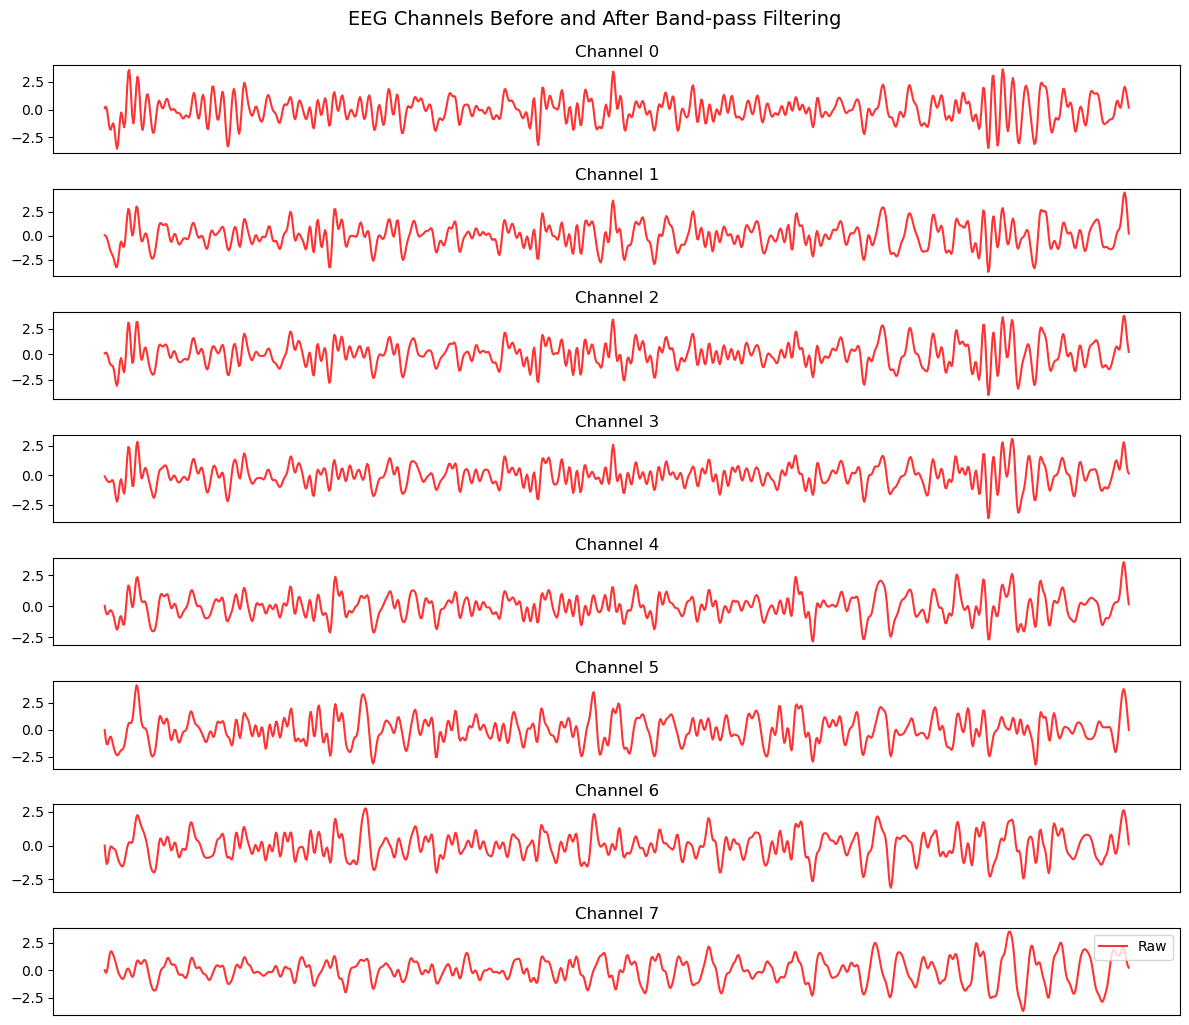

In [10]:
plt.figure(figsize=(12, 10))
example_raw = eeg_train_trials[0]
example_filtered = filtered_train[0]
for i in range(example_raw.shape[1]):
    plt.subplot(8, 1, i + 1)
    # plt.plot(example_raw[:4000, i], color='gray', alpha=0.5, label='Raw')
    plt.plot(example_filtered[:4000, i], color='red', alpha=0.8, label='Filtered')
    plt.title(f"Channel {i}")
    plt.xticks([])
    plt.tight_layout()

plt.legend(['Raw', 'Filtered'], loc='upper right')
plt.suptitle("EEG Channels Before and After Band-pass Filtering", fontsize=14, y=1.02)
plt.show()

In [16]:
def bandpass_filter_band(signal, lowcut, highcut, fs=250, order=4):
    """Apply bandpass filter for a specific frequency band."""
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, signal, axis=0)

# Define 9 frequency bands
filter_bands = [
    (4, 8), (8, 12), (12, 16), (16, 20), (20, 24),
    (24, 28), (28, 32), (32, 36), (36, 40)
]

fs = 250
n_bands = len(filter_bands)
n_trials_train, n_samples, n_channels = filtered_train.shape
n_trials_test = filtered_test.shape[0]

# Apply multi-band filtering to train trials
filtered_multiband_train = np.zeros((n_trials_train, n_bands, n_channels, n_samples))
for trial_idx in range(n_trials_train):
    for b_idx, (low, high) in enumerate(filter_bands):
        for ch_idx in range(n_channels):
            filtered_multiband_train[trial_idx, b_idx, ch_idx, :] = bandpass_filter_band(
                filtered_train[trial_idx, :, ch_idx], low, high, fs
            )

# Apply multi-band filtering to test trials
filtered_multiband_test = np.zeros((n_trials_test, n_bands, n_channels, n_samples))
for trial_idx in range(n_trials_test):
    for b_idx, (low, high) in enumerate(filter_bands):
        for ch_idx in range(n_channels):
            filtered_multiband_test[trial_idx, b_idx, ch_idx, :] = bandpass_filter_band(
                filtered_test[trial_idx, :, ch_idx], low, high, fs
            )

print("filtered_multiband_train shape:", filtered_multiband_train.shape)
print("filtered_multiband_test shape:", filtered_multiband_test.shape)

filtered_multiband_train shape: (164, 9, 8, 1000)
filtered_multiband_test shape: (36, 9, 8, 1000)


NameError: name 'filtered_multiband' is not defined

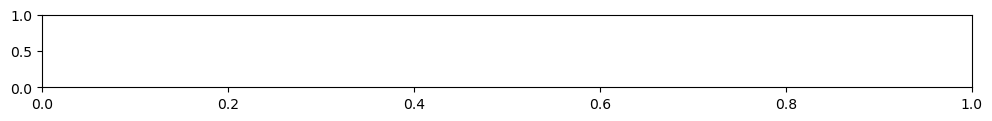

In [17]:
# ===============================================================
# ✅ Verification: visualize 9 frequency bands for one EEG channel
# ===============================================================
import matplotlib.pyplot as plt

# Choose one channel (0 = Fz, 1 = C3, etc.)
channel_idx = 0
channel_name = ch_names[channel_idx] if 'ch_names' in locals() else f"Ch {channel_idx}"

# Choose a short time segment (e.g., first 2 seconds)
fs = 250
start = 0
end = 2 * fs  # 2 seconds

plt.figure(figsize=(12, 10))
for b_idx, (low, high) in enumerate(filter_bands):
    plt.subplot(n_bands, 1, b_idx + 1)
    plt.plot(filtered_multiband[b_idx, channel_idx, start:end], color='tab:red')
    plt.title(f"{channel_name}: Band {b_idx+1} ({low}-{high} Hz)", fontsize=10)
    plt.ylabel('Amplitude (µV)')
    plt.tight_layout()

plt.xlabel("Time (samples)")
plt.suptitle(f"EEG Channel {channel_name} — 9-band Filterbank (first 2 s)", y=1.02, fontsize=13)
plt.show()


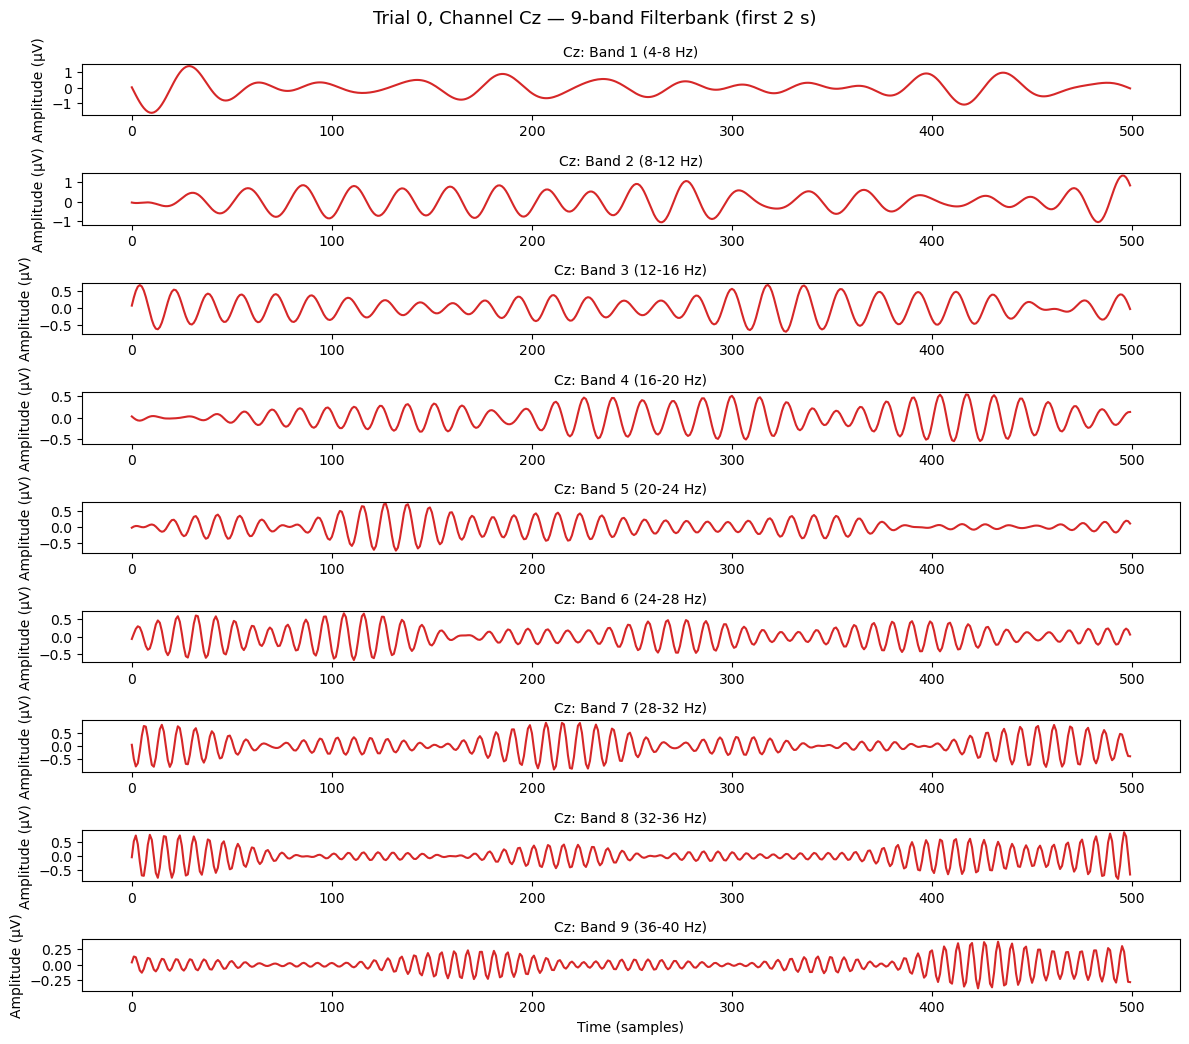

In [18]:
trial_idx = 0
channel_idx = 2
ch_names = ['Fz','C3','Cz','C4','P3','Pz','P4','Oz']
channel_name = ch_names[channel_idx] if channel_idx < len(ch_names) else f"Ch {channel_idx}"

fs = 250
start = 0
end = 2 * fs

plt.figure(figsize=(12, 10))
for b_idx, (low, high) in enumerate(filter_bands):
    plt.subplot(n_bands, 1, b_idx + 1)
    plt.plot(filtered_multiband_train[trial_idx, b_idx, channel_idx, start:end], color='tab:red')
    plt.title(f"{channel_name}: Band {b_idx+1} ({low}-{high} Hz)", fontsize=10)
    plt.ylabel('Amplitude (µV)')
    plt.tight_layout()

plt.xlabel("Time (samples)")
plt.suptitle(f"Trial {trial_idx}, Channel {channel_name} — 9-band Filterbank (first 2 s)", y=1.02, fontsize=13)
plt.show()

In [19]:
from sklearn.preprocessing import StandardScaler

train_flat = filtered_multiband_train.reshape(-1, filtered_multiband_train.shape[2])
test_flat = filtered_multiband_test.reshape(-1, filtered_multiband_test.shape[2])

scaler = StandardScaler()
scaler.fit(train_flat)
train_norm = scaler.transform(train_flat).reshape(filtered_multiband_train.shape)
test_norm = scaler.transform(test_flat).reshape(filtered_multiband_test.shape)

eeg_norm_train = train_norm
eeg_norm_test = test_norm

print("train_norm shape:", eeg_norm_train.shape)
print("test_norm shape:", eeg_norm_test.shape)

train_norm shape: (164, 9, 8, 1000)
test_norm shape: (36, 9, 8, 1000)


In [20]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
label_encoder.fit(np.concatenate([lbl_train_trials, lbl_test_trials]))

lbl_train = label_encoder.transform(lbl_train_trials)
lbl_test = label_encoder.transform(lbl_test_trials)

print("Unique encoded labels (train):", np.unique(lbl_train, return_counts=True))
print("Unique encoded labels (test) :", np.unique(lbl_test, return_counts=True))

Unique encoded labels (train): (array([0, 1]), array([82, 82]))
Unique encoded labels (test) : (array([0, 1]), array([18, 18]))


In [21]:
def create_epochs_multiband(trial_block, label_block, stride, window, amp_thresh=150):
    """
    Slide windows within each trial so labels stay aligned.
    trial_block shape: (N_trials, n_bands, n_channels, n_samples)
    """
    X, y = [], []
    for trial, label in zip(trial_block, label_block):
        n_bands, n_channels, n_samples = trial.shape
        for start in range(0, n_samples - window + 1, stride):
            epoch = trial[:, :, start:start + window]
            if np.max(np.abs(epoch)) < amp_thresh:
                X.append(epoch)
                y.append(label)
    return np.array(X), np.array(y)

In [22]:
window_sec = 1
window_size = fs * window_sec
window_sec_train = 1
window_size_train = fs * window_sec_train
train_stride = window_size_train // 2
test_stride = window_size
amp_thresh = 150

X_train, y_train = create_epochs_multiband(eeg_norm_train, lbl_train,
                                 stride=train_stride, window=window_size_train)
X_test, y_test = create_epochs_multiband(eeg_norm_test, lbl_test,
                               stride=test_stride, window=window_size)

print("Train epochs:", X_train.shape, "Test epochs:", X_test.shape)
print("Train epoch labels:", np.unique(y_train, return_counts=True))
print("Test epoch labels:", np.unique(y_test, return_counts=True))

Train epochs: (1147, 9, 8, 250) Test epochs: (144, 9, 8, 250)
Train epoch labels: (array([0, 1]), array([574, 573]))
Test epoch labels: (array([0, 1]), array([72, 72]))


In [24]:
def normalize_epoch_multiband(epoch):
    mean = epoch.mean(axis=(1, 2), keepdims=True)
    std = epoch.std(axis=(1, 2), keepdims=True) + 1e-8
    return (epoch - mean) / std

X_train = np.array([normalize_epoch_multiband(e) for e in X_train])
X_test = np.array([normalize_epoch_multiband(e) for e in X_test])

print("FBMSNet train shape:", X_train.shape)
print("FBMSNet test shape:", X_test.shape)

FBMSNet train shape: (1147, 9, 8, 250)
FBMSNet test shape: (144, 9, 8, 250)


In [25]:
np.save("X_train_fbmsnet.npy", X_train)
np.save("y_train_fbmsnet.npy", y_train)
np.save("X_test_fbmsnet.npy",  X_test)
np.save("y_test_fbmsnet.npy",  y_test)
